<a href="https://colab.research.google.com/github/Hiraeth-mist/ML-GTEX-Muscle-aging-biomarker-prediction/blob/main/notebooks/04_heatmaps_and_biomarkers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heatmaps and Biomarker Discovery

## Objective

This notebook identifies the most significant age-associated genes in each skeletal muscle type and visualizes their expression patterns using heatmaps.

The goal is to uncover candidate biomarkers and transcriptional signatures associated with skeletal muscle aging.

## Biological Questions

* Which genes exhibit the strongest aging-associated expression changes?
* Do samples cluster according to age based on highly significant genes?
* Are aging signatures shared across muscle types or muscle-specific?

## Deliverables

### Figure 8

EDL Top Differentially Expressed Genes Heatmap

### Figure 9

Soleus Top Differentially Expressed Genes Heatmap

### Figure 10

TA Top Differentially Expressed Genes Heatmap

### Tables

* Top 20 EDL Biomarkers
* Top 20 Soleus Biomarkers
* Top 20 TA Biomarkers

### Outputs

* Publication-quality heatmaps
* Candidate biomarker tables
* Gene ranking tables
* Biological interpretation notes

## Expected Outcome

Identification of key genes driving age-associated transcriptional changes and visualization of aging-related expression signatures across muscle types.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
install.packages(c(
  "pheatmap",
  "ggplot2",
  "dplyr"
))

if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install(c(
  "DESeq2",
  "AnnotationDbi",
  "org.Mm.eg.db"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'DESeq2', 'AnnotationDbi', 'org.Mm.eg.db'

also installing the dependencies ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘XVector’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘png’, ‘Biostrings’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’, ‘RSQLite’, ‘KEGGREST’


Old packages: 'callr', 'openssl', 'pak', 'rstudioapi', 'sessioninfo', 'xtable',
  'zip'



In [2]:
library(DESeq2)
library(pheatmap)
library(ggplot2)
library(dplyr)
library(AnnotationDbi)
library(org.Mm.eg.db)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [3]:
vsd <- readRDS(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/processed/vsd.rds"
)

dds <- readRDS(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/processed/dds.rds"
)

In [4]:
res_edl_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/EDL_DE_results.csv"
)

res_sol_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/SOL_DE_results.csv"
)

res_ta_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/TA_DE_results.csv"
)

In [5]:
head(rownames(vsd))

[1] "ENSMUSG00000000001" "ENSMUSG00000000028" "ENSMUSG00000000056"
[4] "ENSMUSG00000000058" "ENSMUSG00000000078" "ENSMUSG00000000085"

In [6]:
head(res_edl_df$X)

[1] "ENSMUSG00000000001" "ENSMUSG00000000028" "ENSMUSG00000000056"
[4] "ENSMUSG00000000058" "ENSMUSG00000000078" "ENSMUSG00000000085"

In [7]:
gene_symbols <- mapIds(
    org.Mm.eg.db,
    keys = rownames(vsd),
    keytype = "ENSEMBL",
    column = "SYMBOL",
    multiVals = "first"
)

'select()' returned 1:many mapping between keys and columns



In [8]:
head(gene_symbols)

ENSMUSG00000000001 ENSMUSG00000000028 ENSMUSG00000000056 ENSMUSG00000000058 
           "Gnai3"            "Cdc45"             "Narf"             "Cav2" 
ENSMUSG00000000078 ENSMUSG00000000085 
            "Klf6"            "Scmh1"

In [9]:
rowData(vsd)$symbol <- gene_symbols

In [10]:
top30_edl <- head(
    res_edl_df[
        order(res_edl_df$padj),
    ]$X,
    30
)

top30_edl

[1] "ENSMUSG00000038658" "ENSMUSG00000042045" "ENSMUSG00000037685"
 [4] "ENSMUSG00000024803" "ENSMUSG00000023067" "ENSMUSG00000058230"
 [7] "ENSMUSG00000024048" "ENSMUSG00000003031" "ENSMUSG00000027763"
[10] "ENSMUSG00000026459" "ENSMUSG00000063821" "ENSMUSG00000042650"
[13] "ENSMUSG00000028834" "ENSMUSG00000031880" "ENSMUSG00000068614"
[16] "ENSMUSG00000022114" "ENSMUSG00000020190" "ENSMUSG00000055489"
[19] "ENSMUSG00000021768" "ENSMUSG00000041548" "ENSMUSG00000027559"
[22] "ENSMUSG00000027602" "ENSMUSG00000072704" "ENSMUSG00000023232"
[25] "ENSMUSG00000020737" "ENSMUSG00000026335" "ENSMUSG00000007877"
[28] "ENSMUSG00000020722" "ENSMUSG00000030846" "ENSMUSG00000028841"

In [11]:
sum(is.na(
  rowData(vsd)$symbol[
    match(top30_edl, rownames(vsd))
  ]
))

[1] 0

In [12]:
mat_edl <- assay(vsd)[top30_edl, ]

In [13]:
rownames(mat_edl) <- rowData(vsd)$symbol[
    match(
        rownames(mat_edl),
        rownames(vsd)
    )
]

In [14]:
mat_edl_scaled <- t(
    scale(
        t(mat_edl)
    )
)

In [15]:
annotation_col <- data.frame(
    Muscle = colData(vsd)$muscle,
    Age = colData(vsd)$age
)

rownames(annotation_col) <- colnames(mat_edl_scaled)

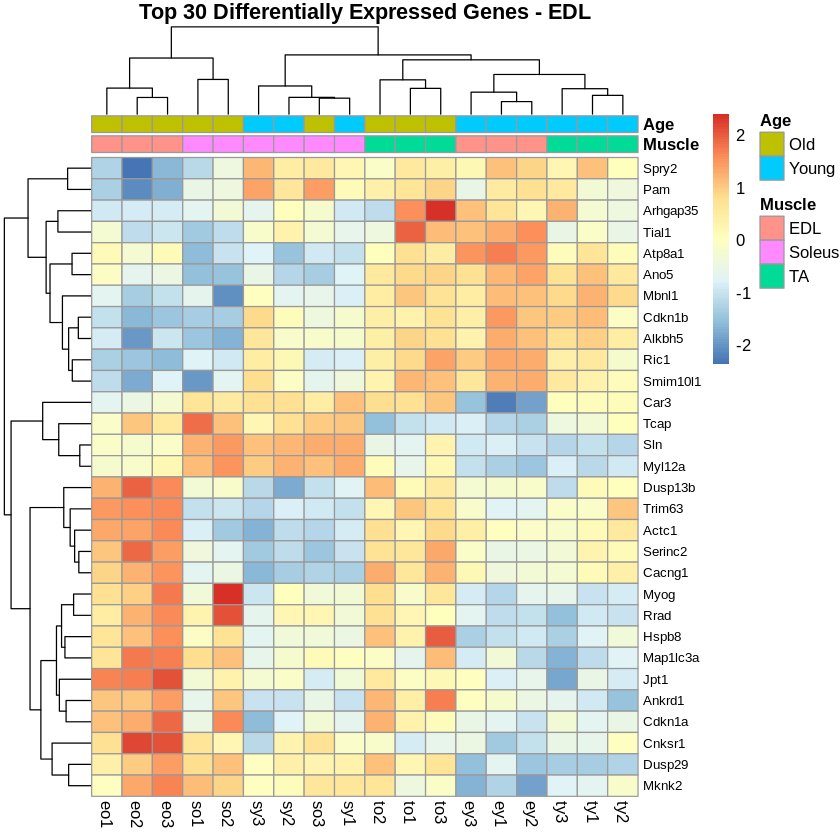

In [16]:
pheatmap(
    mat_edl_scaled,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - EDL"
)

png 
  3

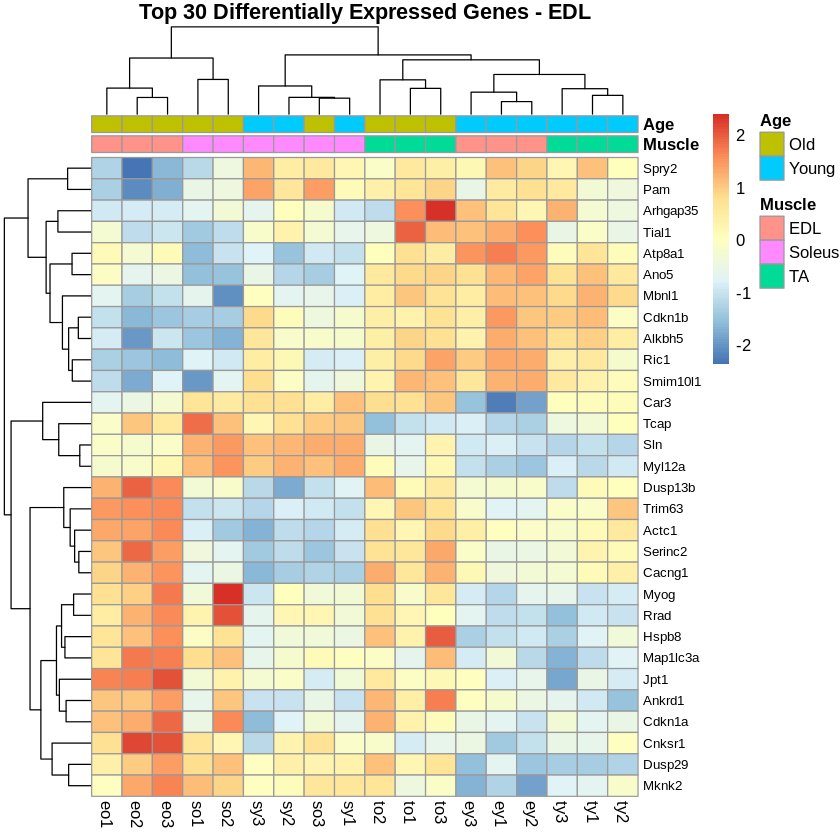

In [17]:
png(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/EDL_top30_heatmap.png",
width = 2200,
height = 2400,
res = 300
)

pheatmap(
    mat_edl_scaled,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - EDL"
)

dev.off()

In [18]:
head(gene_symbols)

ENSMUSG00000000001 ENSMUSG00000000028 ENSMUSG00000000056 ENSMUSG00000000058 
           "Gnai3"            "Cdc45"             "Narf"             "Cav2" 
ENSMUSG00000000078 ENSMUSG00000000085 
            "Klf6"            "Scmh1"

In [19]:
sum(is.na(
  rowData(vsd)$symbol[
    match(top30_edl, rownames(vsd))
  ]
))

[1] 0

In [20]:
make_heatmap <- function(
    res_df,
    vsd,
    title,
    outfile
){

    top30 <- head(
        res_df[
            order(res_df$padj),
        ]$X,
        30
    )

    mat <- assay(vsd)[top30, ]

    rownames(mat) <- rowData(vsd)$symbol[
        match(
            rownames(mat),
            rownames(vsd)
        )
    ]

    mat <- t(scale(t(mat)))

    annotation_col <- data.frame(
        Muscle = colData(vsd)$muscle,
        Age = colData(vsd)$age
    )

    rownames(annotation_col) <- colnames(mat)

    png(
        outfile,
        width = 2200,
        height = 2400,
        res = 300
    )

    pheatmap(
        mat,
        annotation_col = annotation_col,
        show_rownames = TRUE,
        fontsize_row = 8,
        main = title
    )

    dev.off()

    pheatmap(
        mat,
        annotation_col = annotation_col,
        show_rownames = TRUE,
        fontsize_row = 8,
        main = title
    )
}

In [21]:
make_heatmap(
    res_sol_df,
    vsd,
    "Top 30 Differentially Expressed Genes - Soleus",
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/Soleus_top30_heatmap.png"
)

In [22]:
make_heatmap(
    res_ta_df,
    vsd,
    "Top 30 Differentially Expressed Genes - TA",
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/TA_top30_heatmap.png"
)

In [23]:
top30_sol <- head(
    res_sol_df[
        order(res_sol_df$padj),
    ]$X,
    30
)

length(top30_sol)

top30_sol[1:10]

[1] 30

[1] "ENSMUSG00000041559" "ENSMUSG00000028989" "ENSMUSG00000031849"
 [4] "ENSMUSG00000039084" "ENSMUSG00000075376" "ENSMUSG00000030433"
 [7] "ENSMUSG00000074264" "ENSMUSG00000040966" "ENSMUSG00000031994"
[10] "ENSMUSG00000024524"

In [24]:
sum(is.na(
    rowData(vsd)$symbol[
        match(top30_sol, rownames(vsd))
    ]
))

[1] 1

In [25]:
symbols_sol <- rowData(vsd)$symbol[
    match(top30_sol, rownames(vsd))
]

sum(duplicated(symbols_sol))

[1] 0

In [26]:
sum(is.na(res_sol_df$padj))
sum(is.na(res_ta_df$padj))

head(
  res_sol_df[
    order(res_sol_df$padj),
  ],
  5
)

[1] 8

[1] 2451

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8158,ENSMUSG00000041559,442.3093,2.933006,0.3025754,9.693472,3.214134e-22,3.675040e-18
4846,ENSMUSG00000028989,264.2234,2.753140,0.3083732,8.927945,4.339935e-19,2.481141e-15
5862,ENSMUSG00000031849,111.8495,2.673197,0.3080039,8.679102,3.989054e-18,1.520362e-14
7631,ENSMUSG00000039084,134.1212,2.563419,0.3104209,8.257881,1.482811e-16,4.238614e-13
10895,ENSMUSG00000075376,236.7339,-2.211429,0.2817254,-7.849592,4.173933e-15,9.544950e-12


In [27]:
list.files(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps"
)

[1] "EDL_top30_heatmap.png"

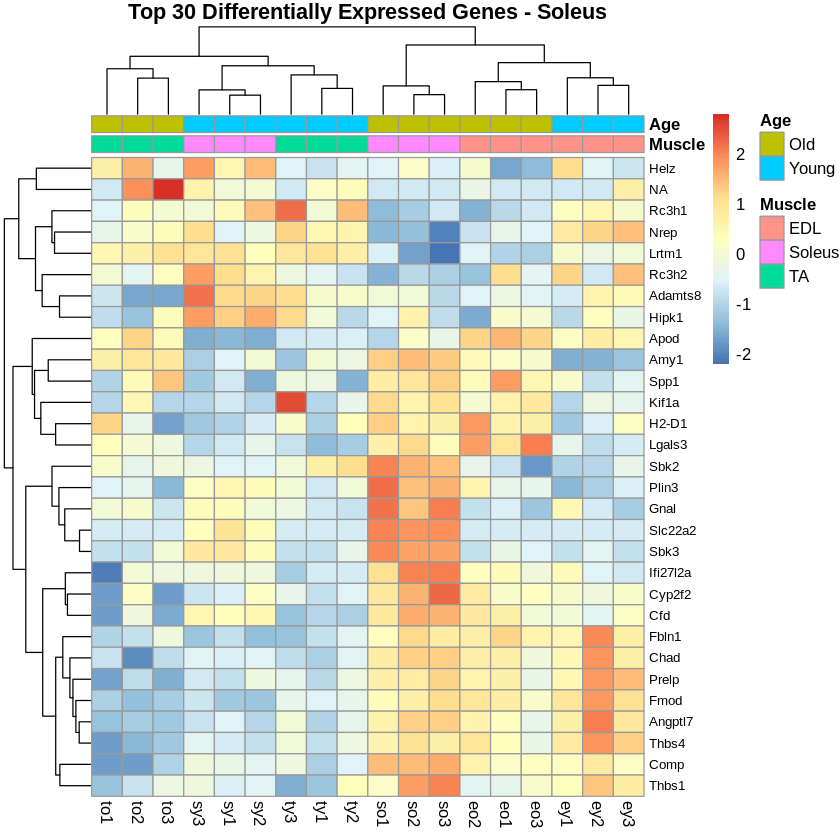

In [28]:
mat_sol <- assay(vsd)[top30_sol, ]

rownames(mat_sol) <- rowData(vsd)$symbol[
    match(
        rownames(mat_sol),
        rownames(vsd)
    )
]

mat_sol <- t(scale(t(mat_sol)))

annotation_col <- data.frame(
    Muscle = colData(vsd)$muscle,
    Age = colData(vsd)$age
)

rownames(annotation_col) <- colnames(mat_sol)

pheatmap(
    mat_sol,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - Soleus"
)

png 
  3

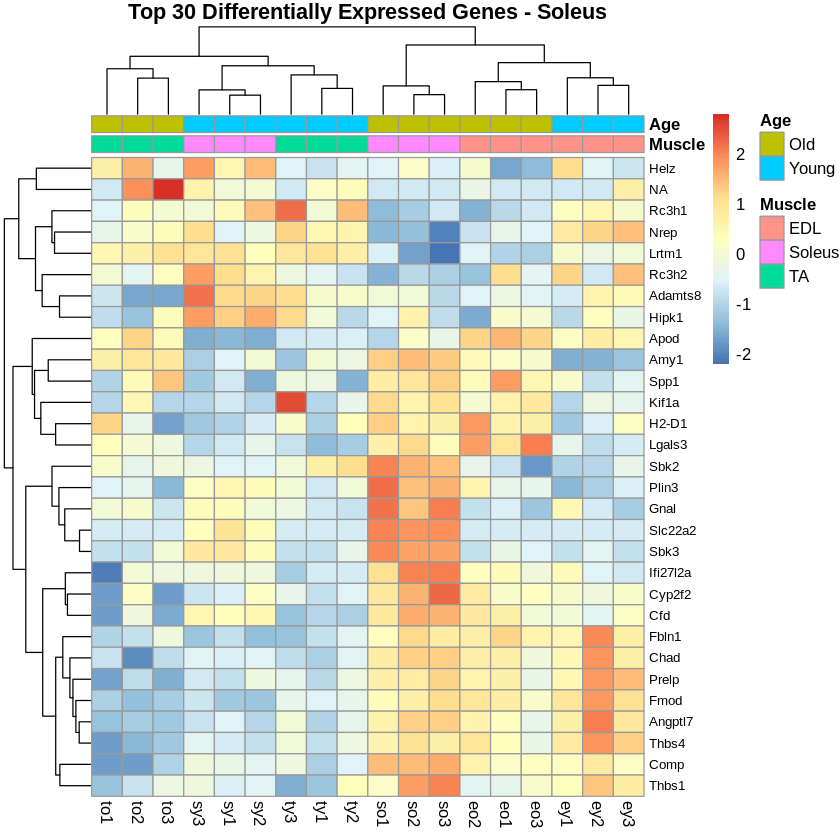

In [29]:
png(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/Soleus_top30_heatmap.png",
width = 2200,
height = 2400,
res = 300
)

pheatmap(
    mat_sol,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - Soleus"
)

dev.off()

In [41]:
pheatmap(
    mat_sol,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - Soleus",
    filename = "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/Soleus_top30_heatmap.pdf",
    width = 8,
    height = 10
)

In [42]:
hm_sol <- pheatmap(
    mat_sol,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - Soleus",
    silent = TRUE
)

pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/Soleus_top30_heatmap.pdf",
width = 8,
height = 10
)

grid::grid.newpage()
grid::grid.draw(hm_sol$gtable)

dev.off()

agg_record_3e223f9bee9 
                     2

In [43]:
pheatmap(
    mat_ta,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - TA",
    filename = "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/TA_top30_heatmap.pdf",
    width = 8,
    height = 10
)

In [44]:
pheatmap(
    mat_edl_scaled,
    annotation_col = annotation_col,
    show_rownames = TRUE,
    fontsize_row = 8,
    main = "Top 30 Differentially Expressed Genes - EDL",
    filename = "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/heatmaps/EDL_top30_heatmap.pdf",
    width = 8,
    height = 10
)

In [37]:
write.csv(
head(res_edl_df[order(res_edl_df$padj),],30),
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top30_EDL_Biomarkers.csv",
row.names = FALSE
)

write.csv(
head(res_sol_df[order(res_sol_df$padj),],30),
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top30_Soleus_Biomarkers.csv",
row.names = FALSE
)

write.csv(
head(res_ta_df[order(res_ta_df$padj),],30),
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top30_TA_Biomarkers.csv",
row.names = FALSE
)

In [38]:
biomarker_summary <- data.frame(
  Muscle = c("EDL","Soleus","TA"),
  Significant_Genes = c(1129,44,105),
  Upregulated = c(204,29,53),
  Downregulated = c(226,11,15)
)

biomarker_summary

write.csv(
biomarker_summary,
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Biomarker_Summary.csv",
row.names = FALSE
)

Muscle,Significant_Genes,Upregulated,Downregulated
<chr>,<dbl>,<dbl>,<dbl>
EDL,1129,204,226
Soleus,44,29,11
TA,105,53,15


## Key Findings

### EDL

EDL exhibited the strongest transcriptional response to aging, with over 1,100 significantly altered genes. Heatmap analysis demonstrated clear separation between young and aged samples based on the top differentially expressed genes.

### Soleus

Soleus displayed a relatively modest aging-associated response, with only 44 significant genes. Despite this, the top genes were sufficient to distinguish young and aged samples.

### TA

TA showed an intermediate response to aging, suggesting muscle-type-specific susceptibility to transcriptional remodeling during aging.

### Overall Conclusion

Distinct skeletal muscle types exhibit markedly different transcriptomic responses to aging, with EDL being the most responsive and Soleus showing relative resilience.